# 04 Baseline Price Forecast
Evaluates naive Moving Median and EWMA (Exponentially Weighted Moving Average) baseline forecasters for 7-day ahead price projections.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

workspace_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

from src.io_utils import load_sample_dataset
from src.clean_prices import clean_price_observations
from src.normalize_prices import normalize_price_series
from src.baseline_forecast import MovingMedianForecaster, EWMAForecaster, evaluate_forecast

## 1. Load Data & Prepare Target Series

In [2]:
products_df = load_sample_dataset("products.csv")
listings_df = load_sample_dataset("product_listings.csv")
obs_df = load_sample_dataset("daily_price_observations.csv")

cleaned_obs = clean_price_observations(obs_df)
norm_df = normalize_price_series(cleaned_obs, listings_df, products_df)

# Focus on Gigabyte RTX 5060 Ti 16GB
target_sku = "RTX5060TI-16G-GIGA-GAMING"
series_df = norm_df[norm_df["sku_id"] == target_sku].groupby("date")["total_effective_price_inr"].median().reset_index()
print(f"Total historical days for {target_sku}: {len(series_df)}")

Total historical days for RTX5060TI-16G-GIGA-GAMING: 13


## 2. Train & Test Split (Holdout 7 Days)

In [3]:
horizon = 7
train_series = series_df["total_effective_price_inr"].iloc[:-horizon]
y_true = series_df["total_effective_price_inr"].iloc[-horizon:].values

# 1. Moving Median
mm_forecaster = MovingMedianForecaster(window=7)
mm_preds = mm_forecaster.fit_predict(train_series, horizon=horizon)
mm_metrics = evaluate_forecast(y_true, mm_preds)

# 2. EWMA
ewma_forecaster = EWMAForecaster(span=7)
ewma_preds = ewma_forecaster.fit_predict(train_series, horizon=horizon)
ewma_metrics = evaluate_forecast(y_true, ewma_preds)

print("=== Baseline Performance (7-Day Holdout) ===")
print("Moving Median (7d):", mm_metrics)
print("EWMA (span 7):     ", ewma_metrics)

=== Baseline Performance (7-Day Holdout) ===
Moving Median (7d): {'MAE_INR': 15142.86, 'RMSE_INR': 15370.75, 'MAPE_Percent': 18.04}
EWMA (span 7):      {'MAE_INR': 14127.23, 'RMSE_INR': 14371.24, 'MAPE_Percent': 16.83}


## 3. Plot Baseline Forecast Comparison

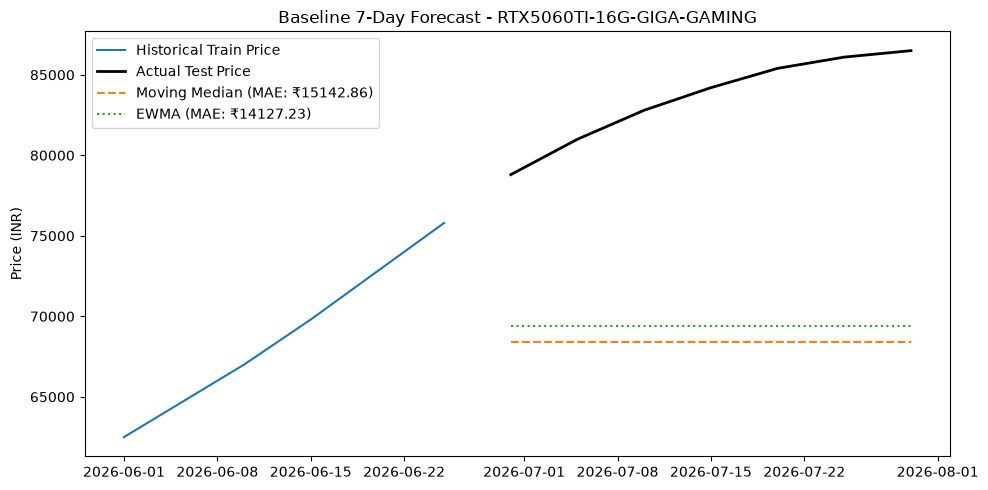

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(series_df["date"].iloc[:-horizon], train_series, label="Historical Train Price")
plt.plot(series_df["date"].iloc[-horizon:], y_true, label="Actual Test Price", color="black", linewidth=2)
plt.plot(series_df["date"].iloc[-horizon:], mm_preds, label=f"Moving Median (MAE: ₹{mm_metrics['MAE_INR']})", linestyle="--")
plt.plot(series_df["date"].iloc[-horizon:], ewma_preds, label=f"EWMA (MAE: ₹{ewma_metrics['MAE_INR']})", linestyle=":")
plt.title(f"Baseline 7-Day Forecast - {target_sku}")
plt.ylabel("Price (INR)")
plt.legend()
plt.tight_layout()
plt.show()